In [1]:
"""
Project mortality effects for forecast ensemble and baseline period
"""

import datetime
import os
import uuid

from dotenv import load_dotenv
import isku
import numpy as np
import xarray as xr

from poreallas.extract import make_climtas, make_tas_monthly_histogram
from poreallas.project import mortality_effect_model, calculate_beta

In [2]:
load_dotenv()
DATA_DIR = "/home/emily_zuetell/projects/poreallas/scripts/data/"

# Input
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
GAMMA_URI = os.environ["POREALLAS_GAMMA_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]
REGIONS_URI = os.environ["POREALLAS_REGIONS_URI"]

# Output
EFFECTS_URI = os.getenv("POREALLAS_EFFECTS_URI")

In [3]:
def read_reanalysis(uri: str) -> xr.Dataset:
    _ds = xr.load_dataset(uri, engine = 'zarr', chunks = {}, backend_kwargs = {"storage_options": {"token": "anon"}})

    # Clean up longitude. The data goes from longitude 0 to 360. It needs to go -180 to 180 in ascending order.
    _ds["longitude"] = (_ds["longitude"] + 180) % 360 - 180
    _ds = _ds.sortby("longitude")
    _ds = _ds.rename({"longitude": "lon", "latitude": "lat"})
    _ds = _ds.chunk("auto")

    return _ds


def read_forecast_ensemble(uri: str) -> xr.Dataset:
    _ds = xr.load_dataset(uri)
    _ds = _ds.sortby("time")
    # Clean up longitude. The data goes from longitude 0 to 360. It needs to go -180 to 180 in ascending order.
    _ds["longitude"] = (_ds["longitude"] + 180) % 360 - 180
    _ds = _ds.sortby("longitude")
    _ds = _ds.rename({"latitude": "lat", "longitude": "lon"})
    _ds = _ds.chunk("auto")

    # TODO: We prob don't want this here. Should be in earlier cleaning. Here for backwards compatibility.
    # Drop months without required number of obs. Forecast ensemble is for a fixed number of days so we expect to usually trim off the last month of the forecast if it is ragged and missing days beyond a threshold.
    _dt_dim = "time"
    _n_initial = _ds[_dt_dim].size
    _number_obs = _ds[_dt_dim].resample(time="ME").count()
    _days_in_month = _number_obs[_dt_dim].dt.days_in_month
    required_percent = 0.9
    _min_req = np.round(_days_in_month * required_percent)
    _qualifying_months = _number_obs.where(_number_obs >= _min_req, drop=True)[
        "time"
    ].dt.month
    _ds = _ds.where(_ds[_dt_dim].dt.month.isin(_qualifying_months), drop=True)

    _n_current = _ds[_dt_dim].size
    _n_initial_months = _number_obs[_dt_dim].size
    _n_qualifying_months = _qualifying_months["time"].size

    print(
        f"continuing with {_n_qualifying_months} of {_n_initial_months} forecast months after removing incomplete months"
    )
    print(
        f"continuing with {_n_current} of {_n_initial} forecast periods after removing incomplete months"
    )

    assert (_n_qualifying_months - _n_initial_months) < 2, (
        "More than one incomplete month was removed from the forecast while checking for incomplete months. Something unexpected is happening."
    )

    return _ds


def read_regions(uri: str) -> isku.GridWeightingRegions:
    _region_weights = xr.load_dataset(uri)[
        ["lat", "lon", "region", "weight"]
    ]  # Load only what we need.
    # Apparently in this version of xarray the `.load()` method type-hints it'll return a DataArray instead of a Dataset.
    # It is a Dataset (I checked). So telling ty to ignore it.
    # # TODO: send bug upstream?
    regions = isku.GridWeightingRegions(_region_weights)  # ty: ignore[invalid-argument-type]
    return regions


def read_gammas(uri: str) -> xr.Dataset:
    return xr.load_dataset(uri)


def read_socioeconomics(uri: str) -> xr.Dataset:
    return xr.load_dataset(uri)

In [4]:
# Read Data
reanalysis = read_reanalysis(ERA5_URI)
forecast_ensemble = read_forecast_ensemble(TAS_FORECAST_URI)
regions = read_regions(REGIONS_URI)
socioeconomics = read_socioeconomics(SOCIOECONOMICS_URI)
gammas = read_gammas(GAMMA_URI)

continuing with 6 of 6 forecast months after removing incomplete months
continuing with 183 of 183 forecast periods after removing incomplete months


/tmp/ipykernel_8814/2033222294.py:54: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [5]:
# Transform gridded data, extracting regional data needed for projections.
histogram_hist_tas = isku.extract_regions(
    reanalysis,
    template=make_tas_monthly_histogram,
    regions=regions,
)
histogram_forecast_tas = isku.extract_regions(
    forecast_ensemble,
    template=make_tas_monthly_histogram,
    regions=regions,
)


In [6]:
# Using the same static beta for forecast and reanalysis projection requires the histogram tas_bin for these data need to be equal, too. So we're  calculating it here.
xr.testing.assert_allclose(
    histogram_hist_tas["tas_bin"],
    histogram_forecast_tas["tas_bin"],
)

climtas = isku.extract_regions(
    reanalysis,
    template=make_climtas,
    regions=regions,
).sel(year=2025, drop=True)
loggdppc = np.log(socioeconomics["gdppc"].sel(year=2023, drop=True))

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


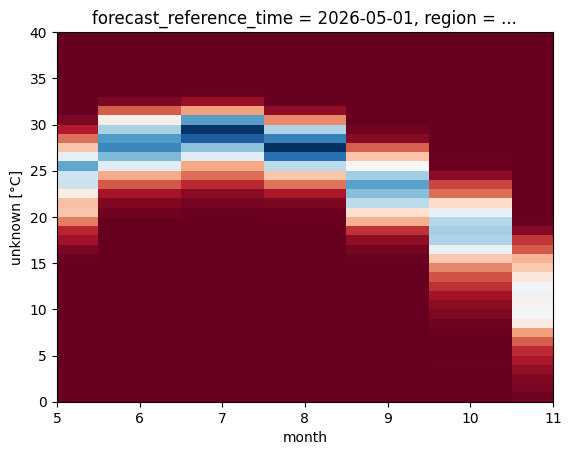

In [17]:
hist_tas = histogram_forecast_tas["histogram_tas"].sel(region = "PAK.2.5.27").sum("number").groupby("time.month").sum("time")
hist_tas.plot(x="month", y="tas_bin", cmap="RdBu", xlim=(5,11), ylim=(0, 40), add_colorbar=False)

In [7]:
# Calculate a fixed response function, i.e. beta.
# Single, static response function with no adaptation is used for both projections.
# Stick everything together and make sure it aligns and matches. Rechunk all together. Also drop any regions with NaNs.
beta_input = (
    xr.Dataset(
        {
            "tas_bin": histogram_forecast_tas["tas_bin"],
            "climtas": climtas["climtas"],
            "loggdppc": loggdppc,
            "gamma": gammas["gamma_mean"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "tas_bin": -1,  # This also needs to be all in memory.
            "age_cohort": 1,  # We're doing all age_cohorts at once but could be done one-by-one.
            "degree": -1,  # For gammas and polynomial calculations. Should all be in memory.
        },
    )
    .unify_chunks()
)
fixed_beta = calculate_beta(beta_input).astype("float32").compute()
fixed_beta["beta"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Temperature mortality rate",
}
# Do beta allowing only hot deaths by 0-ing out everthing on the cold side of the minimum-mortality temperature.
fixed_beta["beta_hotonly"] = fixed_beta["beta"].where(
    fixed_beta["tas_bin"] > fixed_beta["mmt"], other=0
)
fixed_beta["beta_hotonly"].attrs["long_name"] = "Hot temperature mortality rate"

# Do beta, allowing only COLD deaths by 0-ing out everything on the warm side of the minimum-mortality temperature.
fixed_beta["beta_coldonly"] = fixed_beta["beta"].where(
    fixed_beta["tas_bin"] < fixed_beta["mmt"], other=0
)
fixed_beta["beta_coldonly"].attrs["long_name"] = "Cold temperature mortality rate"


/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in subtract
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: invalid value encountered in _uclip_gufunc
  return self.ufunc(*args, **kwargs)


In [9]:
fixed_beta.to_zarr('2608_beta_qdm.zarr')

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [8]:
# Project mortality.
# Start with forecast ensemble.
forecast_input = (
    xr.Dataset(
        {
            "histogram_tas": histogram_forecast_tas["histogram_tas"],
            "beta": fixed_beta["beta"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "time": -1,
            "tas_bin": -1,
            "age_cohort": 1,
            "number": 1,
        },
    )
    .unify_chunks()
)
projected_forecast = isku.project(
    forecast_input, model=mortality_effect_model
).compute()
projected_forecast["effect"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Temperature mortality",
}



In [9]:
# Now hot-only projection
forecast_input = (
    xr.Dataset(
        {
            "histogram_tas": histogram_forecast_tas["histogram_tas"],
            "beta": fixed_beta["beta_hotonly"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "time": -1,
            "tas_bin": -1,
            "age_cohort": 1,
            "number": 1,
        },
    )
    .unify_chunks()
)
projected_forecast_hotonly = isku.project(
    forecast_input, model=mortality_effect_model
).compute()
projected_forecast_hotonly["effect"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Hot temperature mortality",
}



In [13]:
# Now cold-only projection
forecast_input = (
    xr.Dataset(
        {
            "histogram_tas": histogram_forecast_tas["histogram_tas"],
            "beta": fixed_beta["beta_coldonly"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "time": -1,
            "tas_bin": -1,
            "age_cohort": 1,
            "number": 1,
        },
    )
    .unify_chunks()
)
projected_forecast_coldonly = isku.project(
    forecast_input, model=mortality_effect_model
).compute()
projected_forecast_coldonly["effect"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Cold temperature mortality",
}



In [10]:
# Now do the baseline period.
# Stick everything together and make sure it aligns and matches. Rechunk all together. Also drop any regions with NaNs.
hist_input = (
    xr.Dataset(
        {
            "histogram_tas": histogram_hist_tas["histogram_tas"],
            "beta": fixed_beta["beta"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "time": -1,
            "tas_bin": -1,
            "age_cohort": 1,
        },
    )
    .unify_chunks()
)
projected_hist = isku.project(hist_input, model=mortality_effect_model).compute()
projected_hist["effect"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Temperature mortality",
}


In [11]:
# Now hot-only projection
hist_input = (
    xr.Dataset(
        {
            "histogram_tas": histogram_hist_tas["histogram_tas"],
            "beta": fixed_beta["beta_hotonly"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "time": -1,
            "tas_bin": -1,
            "age_cohort": 1,
        },
    )
    .unify_chunks()
)
projected_hist_hotonly = isku.project(
    hist_input, model=mortality_effect_model
).compute()
projected_hist_hotonly["effect"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Hot temperature mortality",
}



In [12]:
# Now cold-only projection
hist_input = (
    xr.Dataset(
        {
            "histogram_tas": histogram_hist_tas["histogram_tas"],
            "beta": fixed_beta["beta_coldonly"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "time": -1,
            "tas_bin": -1,
            "age_cohort": 1,
        },
    )
    .unify_chunks()
)
projected_hist_coldonly = isku.project(
    hist_input, model=mortality_effect_model
).compute()
projected_hist_coldonly["effect"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Cold temperature mortality",
}

In [14]:
# Collect everything and write to storage.
_out = {
    "forecast": projected_forecast,
    "baseline": projected_hist,
    "forecast_hotonly": projected_forecast_hotonly,
    "baseline_hotonly": projected_hist_hotonly,
    "forecast_coldonly": projected_forecast_coldonly,
    "baseline_coldonly": projected_hist_coldonly,
}
_out_dt = xr.DataTree.from_dict(_out)

# Add metadata
_uid = str(uuid.uuid4())
_datetime_now = datetime.datetime.now(datetime.timezone.utc).isoformat()

_out_dt.attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Projected temperature mortality effects",
}

_out_dt["forecast"].attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Forecast ensemble projected temperature mortality effects",
    "poreallas_temperature_uri": TAS_FORECAST_URI,
    "poreallas_socioeconomics_uri": SOCIOECONOMICS_URI,
    "poreallas_model_parameters_uri": GAMMA_URI,
    "poreallas_regions_uri": REGIONS_URI,
}

_out_dt["baseline"].attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Baseline projected temperature mortality effects",
    "poreallas_temperature_uri": ERA5_URI,
    "poreallas_socioeconomics_uri": SOCIOECONOMICS_URI,
    "poreallas_model_parameters_uri": GAMMA_URI,
    "poreallas_regions_uri": REGIONS_URI,
}

_out_dt["forecast_hotonly"].attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Forecast ensemble projected hot temperature mortality effects",
    "poreallas_temperature_uri": TAS_FORECAST_URI,
    "poreallas_socioeconomics_uri": SOCIOECONOMICS_URI,
    "poreallas_model_parameters_uri": GAMMA_URI,
    "poreallas_regions_uri": REGIONS_URI,
}

_out_dt["baseline_hotonly"].attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Baseline projected hot temperature mortality effects",
    "poreallas_temperature_uri": ERA5_URI,
    "poreallas_socioeconomics_uri": SOCIOECONOMICS_URI,
    "poreallas_model_parameters_uri": GAMMA_URI,
    "poreallas_regions_uri": REGIONS_URI,
}

_out_dt["forecast_coldonly"].attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Forecast ensemble projected cold temperature mortality effects",
    "poreallas_temperature_uri": TAS_FORECAST_URI,
    "poreallas_socioeconomics_uri": SOCIOECONOMICS_URI,
    "poreallas_model_parameters_uri": GAMMA_URI,
    "poreallas_regions_uri": REGIONS_URI,
}

_out_dt["baseline_coldonly"].attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Baseline projected cold temperature mortality effects",
    "poreallas_temperature_uri": ERA5_URI,
    "poreallas_socioeconomics_uri": SOCIOECONOMICS_URI,
    "poreallas_model_parameters_uri": GAMMA_URI,
    "poreallas_regions_uri": REGIONS_URI,
}


_out_dt.to_zarr("/home/emily_zuetell/projects/poreallas/data/2608_effect.zarr", consolidated=True)
print(f"Effects written to ")

Effects written to 


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 0, 'Effect [deaths/100k]')

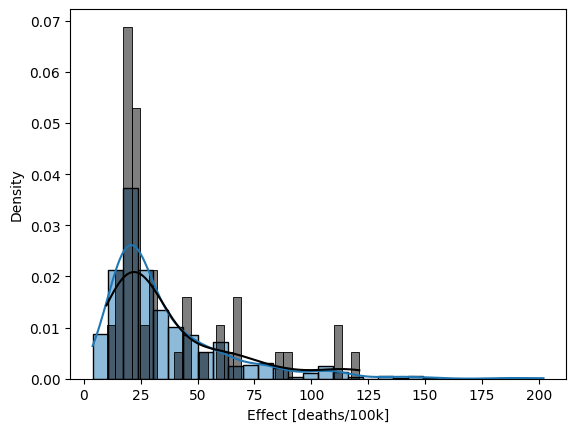

In [36]:
fig, ax = plt.subplots()
mean = projected_forecast["effect"].sel(region = 'CHN.11.109.767', time = '2026-07-01', age_cohort = 'age65plus', sample = 1)
sampled = projected_forecast["effect"].sel(region = 'CHN.11.109.767', time = '2026-07-01', age_cohort = 'age65plus')

sns.histplot(sampled.values.flatten(), kde=True, bins=30, ax = ax, stat = 'density')
sns.histplot(mean.values.flatten(), kde=True, bins=30, ax = ax, stat = 'density', color = 'k')
ax.set_xlabel('Effect [deaths/100k]')

In [ ]:
# Now hot-only projection
forecast_input = (
    xr.Dataset(
        {
            "histogram_tas": histogram_forecast_tas["histogram_tas"],
            "beta": fixed_beta["beta_hotonly"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "time": -1,
            "tas_bin": -1,
            "age_cohort": 1,
            "number": 1,
        },
    )
    .unify_chunks()
)
projected_forecast_hotonly = isku.project(
    forecast_input, model=mortality_effect_model
).compute()
projected_forecast_hotonly["effect"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Hot temperature mortality",
}

# Now do the baseline period.
# Stick everything together and make sure it aligns and matches. Rechunk all together. Also drop any regions with NaNs.
hist_input = (
    xr.Dataset(
        {
            "histogram_tas": histogram_hist_tas["histogram_tas"],
            "beta": fixed_beta["beta"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "time": -1,
            "tas_bin": -1,
            "age_cohort": 1,
        },
    )
    .unify_chunks()
)
projected_hist = isku.project(hist_input, model=mortality_effect_model).compute()
projected_hist["effect"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Temperature mortality",
}
# Now hot-only projection
hist_input = (
    xr.Dataset(
        {
            "histogram_tas": histogram_hist_tas["histogram_tas"],
            "beta": fixed_beta["beta_hotonly"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "time": -1,
            "tas_bin": -1,
            "age_cohort": 1,
        },
    )
    .unify_chunks()
)
projected_hist_hotonly = isku.project(
    hist_input, model=mortality_effect_model
).compute()
projected_hist_hotonly["effect"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Hot temperature mortality",
}

# Collect everything and write to storage.
_out = {
    "forecast": projected_forecast,
    "baseline": projected_hist,
    "forecast_hotonly": projected_forecast_hotonly,
    "baseline_hotonly": projected_hist_hotonly,
}
_out_dt = xr.DataTree.from_dict(_out)

# Add metadata
_uid = str(uuid.uuid4())
_datetime_now = datetime.datetime.now(datetime.timezone.utc).isoformat()

_out_dt.attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Projected temperature mortality effects",
}

_out_dt["forecast"].attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Forecast ensemble projected temperature mortality effects",
    "poreallas_temperature_uri": TAS_FORECAST_URI,
    "poreallas_socioeconomics_uri": SOCIOECONOMICS_URI,
    "poreallas_model_parameters_uri": GAMMA_URI,
    "poreallas_regions_uri": REGIONS_URI,
}

_out_dt["baseline"].attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Baseline projected temperature mortality effects",
    "poreallas_temperature_uri": ERA5_URI,
    "poreallas_socioeconomics_uri": SOCIOECONOMICS_URI,
    "poreallas_model_parameters_uri": GAMMA_URI,
    "poreallas_regions_uri": REGIONS_URI,
}

_out_dt["forecast_hotonly"].attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Forecast ensemble projected hot temperature mortality effects",
    "poreallas_temperature_uri": TAS_FORECAST_URI,
    "poreallas_socioeconomics_uri": SOCIOECONOMICS_URI,
    "poreallas_model_parameters_uri": GAMMA_URI,
    "poreallas_regions_uri": REGIONS_URI,
}

_out_dt["baseline_hotonly"].attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Baseline projected hot temperature mortality effects",
    "poreallas_temperature_uri": ERA5_URI,
    "poreallas_socioeconomics_uri": SOCIOECONOMICS_URI,
    "poreallas_model_parameters_uri": GAMMA_URI,
    "poreallas_regions_uri": REGIONS_URI,
}

if EFFECTS_URI is not None:
    _out_dt.to_zarr(EFFECTS_URI, consolidated=False)
    print(f"Effects written to {EFFECTS_URI}")